# 04 · Results, Analysis & Conclusions
Report sections: *Results* + *Analysis*. Loads the per-notebook result CSVs (no model refit) for the comparison, then runs the dimensionality-reduction ablation.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data.pipeline import build_dataset
from src.baselines import PCA, GaussianClassifier, KNNClassifier
from src.extension import SAMMEClassifier
from src.metrics import accuracy, collapse_winner
from src.plotting import (save_fig, plot_sweep, plot_decision_regions,
                          use_report_style, nice_label)
use_report_style()

## 1. Consolidated comparison
Baselines (02) + SAMME (03) + naive + market, on the original-corner test.

In [2]:
base = pd.read_csv('../report/results_baselines.csv', index_col='model')
ext = pd.read_csv('../report/results_extension.csv', index_col='model')
table = pd.concat([ext, base])
ds = build_dataset(seed=0)
ar = (collapse_winner(ds.y_test.values) == 'Red').mean()
print(f'always-red winner = {ar:.3f}   coin-flip = 0.500   market log-loss = 1.551')
table.round(3)

always-red winner = 0.562   coin-flip = 0.500   market log-loss = 1.551


,acc6_mean,acc6_std,winner_mean,winner_std,method_mean,macro_f1_mean,roc_auc_mean,logloss_mean
model,,,,,,,,
SAMME,0.349,0.012,0.633,0.016,0.515,0.297,0.698,1.663
LDA,0.343,0.004,0.626,0.004,0.516,0.315,0.685,1.592
QDA,0.230,0.018,0.567,0.029,0.371,0.220,0.624,3.134
kNN (k=15),0.282,0.004,0.550,0.006,0.497,0.221,0.595,3.642
majority,0.266,0.025,0.521,0.059,0.514,0.070,0.500,1.702


In [ ]:
# Macro-F1 and ROC-AUC by model (read straight from the per-notebook result CSVs - no refit)
t = pd.concat([pd.read_csv('../report/results_extension.csv', index_col='model'),
               pd.read_csv('../report/results_baselines.csv', index_col='model')])
mods = [m for m in ['SAMME', 'LDA', 'QDA', 'kNN (k=15)', 'majority'] if m in t.index]
t = t.loc[mods]; x = np.arange(len(mods)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w/2, t['macro_f1_mean'], w, label='macro-F1', color='steelblue')
ax.bar(x + w/2, t['roc_auc_mean'], w, label='ROC-AUC (OvR)', color='seagreen')
ax.axhline(0.5, ls=':', c='k', lw=1, label='ROC-AUC chance')
for i, (f, a) in enumerate(zip(t['macro_f1_mean'], t['roc_auc_mean'])):
    ax.annotate(f'{f:.2f}', (i - w/2, f), ha='center', va='bottom', fontsize=9)
    ax.annotate(f'{a:.2f}', (i + w/2, a), ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(mods, rotation=20, ha='right')
ax.set_ylabel('score (6-class target)'); ax.set_ylim(0, 0.85); ax.legend()
ax.set_title('Macro-F1 and ROC-AUC by model')
plt.tight_layout(); save_fig('metrics_f1_auc'); plt.show()

In [ ]:
# Winner (Red vs Blue) ROC curves - the actual ROC, not just the scalar AUC.
# P(Red win) = sum of the three Red-* class probabilities; positive class = Red.
from src.metrics import roc_curve
auc_trap = lambda fpr, tpr: float(np.sum(np.diff(fpr) * (tpr[1:] + tpr[:-1]) / 2))  # trapezoid area
Xtr_, ytr_, Xte_, yte_ = ds.X_train.values, ds.y_train.values, ds.X_test.values, ds.y_test.values
ywin = (collapse_winner(yte_) == 'Red').astype(int)
roc_models = [('SAMME', SAMMEClassifier(n_estimators=200)), ('LDA', GaussianClassifier('lda')),
              ('QDA', GaussianClassifier('qda', reg=1.0)), ('kNN (k=15)', KNNClassifier(k=15))]
fig, ax = plt.subplots(figsize=(6.5, 6))
for name, m in roc_models:
    m.fit(Xtr_, ytr_); proba = m.predict_proba(Xte_)
    red = [i for i, c in enumerate(m.classes_) if str(c).startswith('Red')]
    fpr, tpr = roc_curve(ywin, proba[:, red].sum(1))
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_trap(fpr, tpr):.3f})')
ax.plot([0, 1], [0, 1], 'r--', label='random (AUC=0.5)')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('Winner (Red vs Blue) ROC curves'); ax.legend(loc='lower right')
plt.tight_layout(); save_fig('roc_curves'); plt.show()

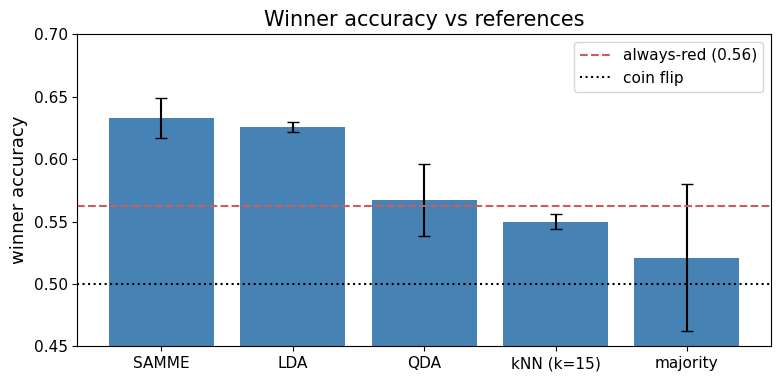

In [3]:
order = [m for m in ['SAMME','LDA','QDA','kNN (k=15)','majority'] if m in table.index]
means = table.loc[order,'winner_mean']; stds = table.loc[order,'winner_std'].fillna(0)
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(order, means, yerr=stds, capsize=4, color='steelblue')
ax.axhline(ar, ls='--', c='indianred', label=f'always-red ({ar:.2f})')
ax.axhline(0.5, ls=':', c='k', label='coin flip')
ax.set_ylabel('winner accuracy'); ax.set_ylim(0.45,0.7); ax.legend(); ax.set_title('Winner accuracy vs references')
plt.tight_layout(); save_fig('model_comparison'); plt.show()

## 1b. Decision regions (model inductive bias)
Each model re-fit on the two most predictive features and its predicted winner region shaded. This is a 2D stand-in, not the full model, but it shows *how* each method carves space: LDA a straight line, QDA a curve, kNN ragged local pockets, SAMME axis-aligned boxes (its decision stumps). The heavy red/blue overlap is why accuracy stays near the ceiling.

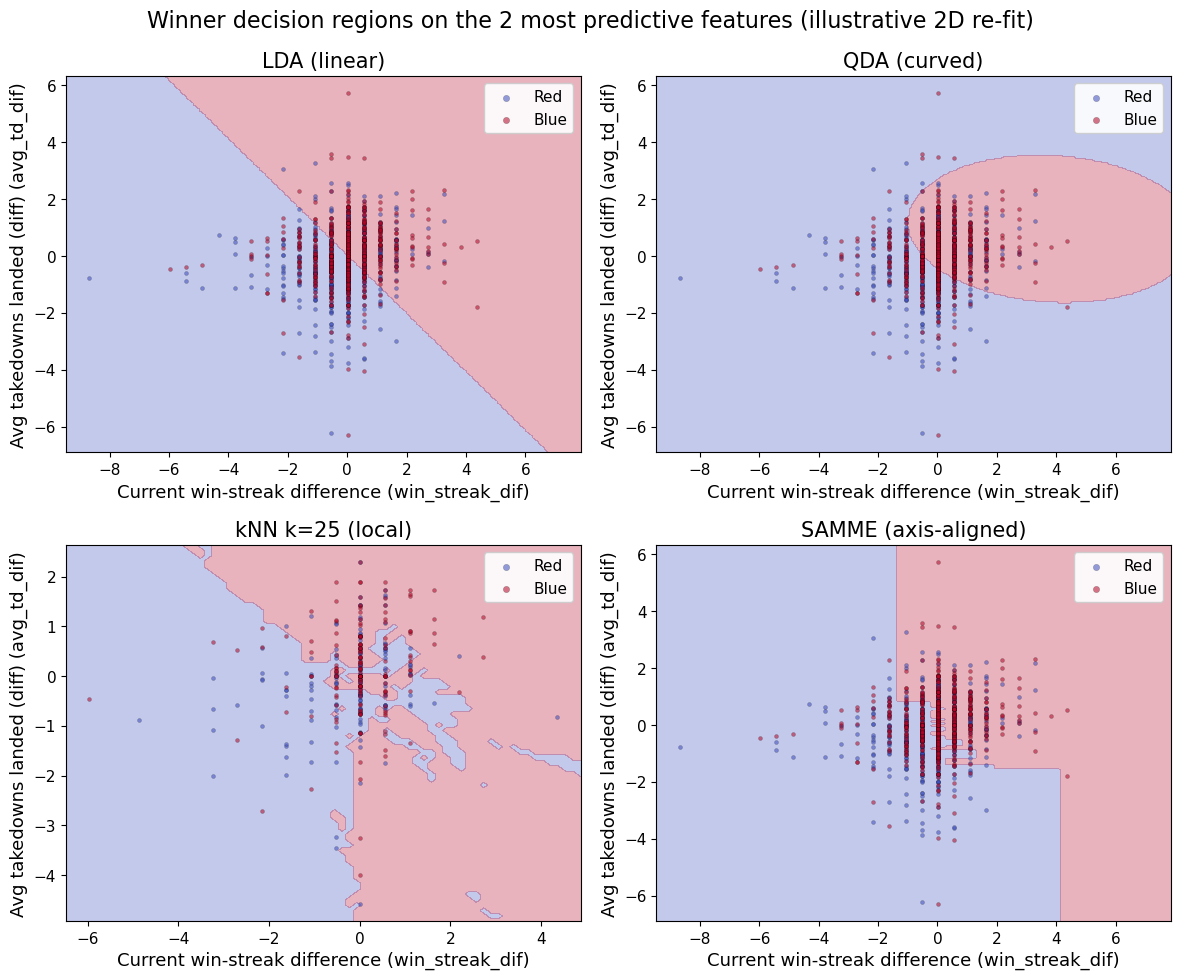

In [4]:
# Decision regions on the 2 most predictive features (winner target). Illustrative 2D RE-FIT,
# not the real ~114-D model - it shows each method's inductive bias (linear vs curved vs local vs boxy).
feats = ['win_streak_dif', 'avg_td_dif']
Xf = ds.X_train[feats].values; yf = collapse_winner(ds.y_train.values)
rng = np.random.default_rng(0); sub = rng.choice(len(Xf), 350, replace=False)  # kNN grid is slow; subsample
classes = ['Red', 'Blue']
jobs = [('LDA (linear)', GaussianClassifier('lda'), Xf, yf, 250),
        ('QDA (curved)', GaussianClassifier('qda', reg=1e-3), Xf, yf, 250),
        ('kNN k=25 (local)', KNNClassifier(k=25), Xf[sub], yf[sub], 70),
        ('SAMME (axis-aligned)', SAMMEClassifier(n_estimators=200), Xf, yf, 180)]
fig, axes = plt.subplots(2, 2, figsize=(12, 10)); axes = axes.ravel()
for (name, m, X2, y2, res), ax in zip(jobs, axes):
    m.fit(X2, y2)
    plot_decision_regions(m, X2, y2, classes, xlabel=nice_label(feats[0]),
                          ylabel=nice_label(feats[1]), ax=ax, resolution=res)
    ax.set_title(name)
fig.suptitle('Winner decision regions on the 2 most predictive features (illustrative 2D re-fit)')
plt.tight_layout(); save_fig('decision_regions'); plt.show()

## 2. Dimensionality-reduction ablation (E3)
Does PCA rescue QDA / kNN, which struggle in ~114 dimensions? Scree curve, then winner accuracy vs number of components.

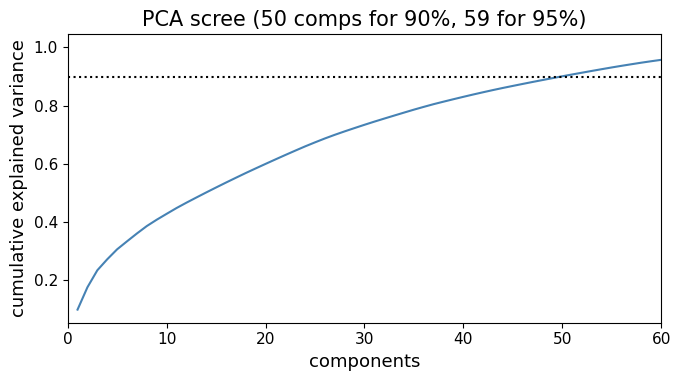

50 components explain 90% of variance, 59 explain 95%


In [5]:
Xtr, ytr, Xte, yte = ds.X_train.values, ds.y_train.values, ds.X_test.values, ds.y_test.values
ywin = collapse_winner(yte)
pca = PCA().fit(Xtr)
cum = np.cumsum(pca.explained_variance_ratio_)
d90 = int(np.argmax(cum >= 0.90)) + 1; d95 = int(np.argmax(cum >= 0.95)) + 1
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(range(1, len(cum)+1), cum, color='steelblue'); ax.axhline(0.9, ls=':', c='k')
ax.set_xlabel('components'); ax.set_ylabel('cumulative explained variance'); ax.set_xlim(0,60)
ax.set_title(f'PCA scree ({d90} comps for 90%, {d95} for 95%)')
plt.tight_layout(); save_fig('pca_scree'); plt.show()
print(f'{d90} components explain 90% of variance, {d95} explain 95%')

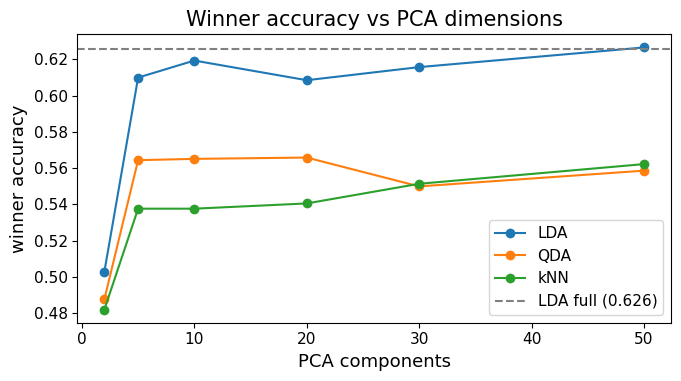

LDA: best PCA winner-acc = 0.627 at d=50 (full-feature was QDA 0.567 / kNN 0.550)
QDA: best PCA winner-acc = 0.566 at d=20 (full-feature was QDA 0.567 / kNN 0.550)
kNN: best PCA winner-acc = 0.562 at d=50 (full-feature was QDA 0.567 / kNN 0.550)


In [6]:
dims = [2, 5, 10, 20, 30, 50]
specs = {'LDA': lambda: GaussianClassifier('lda'),
         'QDA': lambda: GaussianClassifier('qda', reg=1e-3),
         'kNN': lambda: KNNClassifier(k=15)}
curves = {n: [] for n in specs}
for d in dims:
    p = PCA(n_components=d).fit(Xtr)
    Ztr, Zte = p.transform(Xtr), p.transform(Xte)
    for n, make in specs.items():
        m = make().fit(Ztr, ytr)
        curves[n].append(accuracy(ywin, collapse_winner(m.predict(Zte))))
fig, ax = plt.subplots(figsize=(7,4))
for n in specs: ax.plot(dims, curves[n], marker='o', label=n)
ax.axhline(0.626, ls='--', c='grey', label='LDA full (0.626)')
ax.set_xlabel('PCA components'); ax.set_ylabel('winner accuracy'); ax.legend(); ax.set_title('Winner accuracy vs PCA dimensions')
plt.tight_layout(); save_fig('pca_sweep'); plt.show()
for n in specs: print(f'{n}: best PCA winner-acc = {max(curves[n]):.3f} at d={dims[int(np.argmax(curves[n]))]} (full-feature was QDA 0.567 / kNN 0.550)')

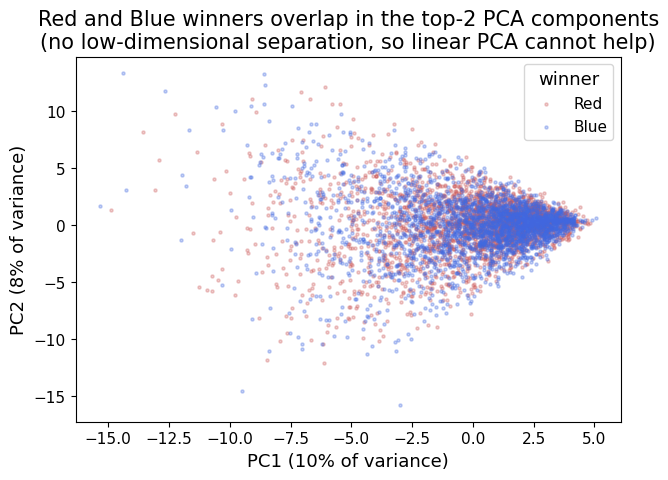

In [7]:
# 2D PCA scatter coloured by winner - the takeaway is the *overlap* (no low-dim separation)
p2 = PCA(n_components=2).fit(Xtr); Z = p2.transform(Xtr)
fig, ax = plt.subplots(figsize=(6.5, 5))
for cls, c in [('Red', 'indianred'), ('Blue', 'royalblue')]:
    mask = collapse_winner(ytr) == cls
    ax.scatter(Z[mask, 0], Z[mask, 1], s=5, alpha=0.3, color=c, label=cls)
ax.set_xlabel(f'PC1 ({p2.explained_variance_ratio_[0]:.0%} of variance)')
ax.set_ylabel(f'PC2 ({p2.explained_variance_ratio_[1]:.0%} of variance)')
ax.legend(title='winner')
ax.set_title('Red and Blue winners overlap in the top-2 PCA components\n(no low-dimensional separation, so linear PCA cannot help)')
plt.tight_layout(); save_fig('pca_2d'); plt.show()

## 3. Discussion & conclusions
See report Sections 8 and 9. Headline: best models reach ~0.63 winner accuracy (in the published ceiling); SAMME ties LDA, so the added complexity does not pay off here; the market still edges us on log-loss but we are close; QDA/kNN are weak in high dimensions, and the ablation above shows whether DR recovers them.

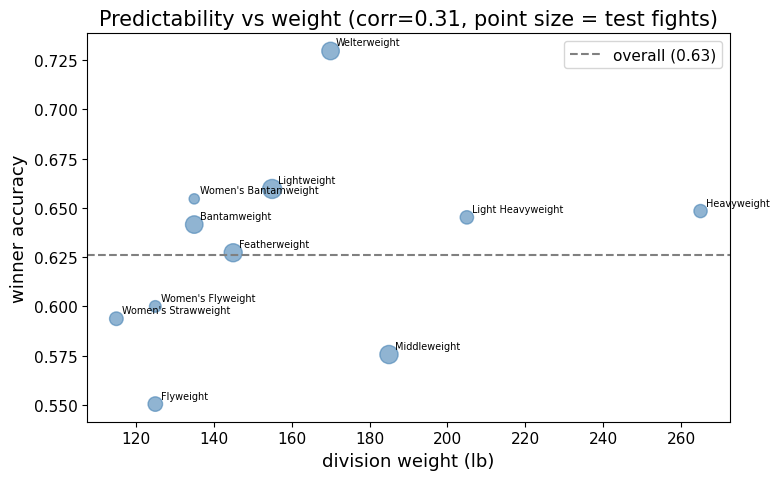

correlation(weight, accuracy) = 0.31  (near 0 => no weight trend)
        weight_class  lb   n   acc
 Women's Strawweight 115  96 0.594
           Flyweight 125 109 0.550
   Women's Flyweight 125  70 0.600
        Bantamweight 135 159 0.642
Women's Bantamweight 135  55 0.655
       Featherweight 145 169 0.627
         Lightweight 155 188 0.660
        Welterweight 170 159 0.730
        Middleweight 185 172 0.576
   Light Heavyweight 205  93 0.645
         Heavyweight 265  91 0.648


In [8]:
# Predictability by weight class: winner accuracy vs the division's weight (lb)
from src.data.load import load_clean
from src.baselines import GaussianClassifier
df_raw, _ = load_clean()
lda = GaussianClassifier('lda').fit(ds.X_train.values, ds.y_train.values)
pwin = collapse_winner(lda.predict(ds.X_test.values)); ywin2 = collapse_winner(ds.y_test.values)
wc = df_raw.loc[ds.test_index, 'weight_class']
WEIGHT_LB = {'Strawweight':115, "Women's Strawweight":115, 'Flyweight':125, "Women's Flyweight":125,
             'Bantamweight':135, "Women's Bantamweight":135, 'Featherweight':145, "Women's Featherweight":145,
             'Lightweight':155, 'Welterweight':170, 'Middleweight':185, 'Light Heavyweight':205, 'Heavyweight':265}
rows = [(w, WEIGHT_LB[w], (wc==w).sum(), accuracy(ywin2[(wc==w).values], pwin[(wc==w).values]))
        for w in wc.unique() if (wc==w).sum() >= 40 and w in WEIGHT_LB]
wcdf = pd.DataFrame(rows, columns=['weight_class','lb','n','acc']).sort_values('lb')
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(wcdf['lb'], wcdf['acc'], s=wcdf['n'], alpha=0.6, color='steelblue')
for _, r in wcdf.iterrows(): ax.annotate(r['weight_class'], (r['lb'], r['acc']), fontsize=7, xytext=(4,4), textcoords='offset points')
ax.axhline(0.626, ls='--', c='grey', label='overall (0.63)')
ax.set_xlabel('division weight (lb)'); ax.set_ylabel('winner accuracy'); ax.legend()
corr = np.corrcoef(wcdf['lb'], wcdf['acc'])[0, 1]
ax.set_title(f'Predictability vs weight (corr={corr:.2f}, point size = test fights)')
plt.tight_layout(); save_fig('accuracy_by_weightclass'); plt.show()
print(f'correlation(weight, accuracy) = {corr:.2f}  (near 0 => no weight trend)')
print(wcdf.round(3).to_string(index=False))

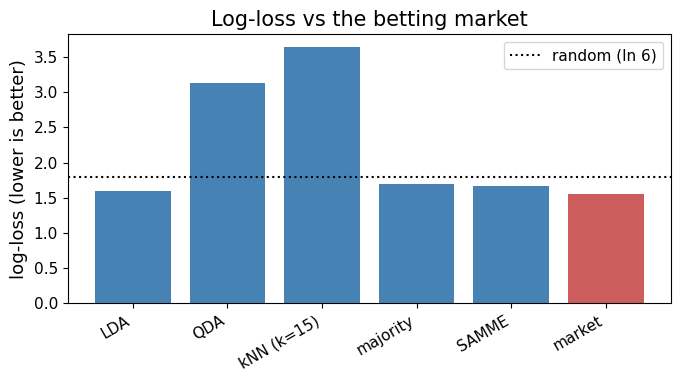

In [9]:
# Log-loss: our models vs the betting market
ours = pd.concat([pd.read_csv('../report/results_baselines.csv', index_col='model'),
                  pd.read_csv('../report/results_extension.csv', index_col='model')])['logloss_mean']
names = list(ours.index) + ['market']; vals = list(ours.values) + [1.551]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(names, vals, color=['steelblue']*len(ours) + ['indianred'])
ax.axhline(np.log(6), ls=':', c='k', label='random (ln 6)')
ax.set_ylabel('log-loss (lower is better)'); ax.legend(); ax.set_title('Log-loss vs the betting market')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); save_fig('logloss_comparison'); plt.show()